In [1]:
import pandas as pd

df = pd.read_csv('../data/netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [2]:
df.shape

(8807, 12)

In [3]:
df.columns
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [4]:
df.dropna(subset=['date_added'], inplace=True)

In [5]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

In [6]:
df.dropna(subset=['date_added'], inplace=True)

In [7]:
df['year_added'] = df['date_added'].dt.year

In [8]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2541
cast             817
country          827
date_added         0
release_year       0
rating             4
duration           3
listed_in          0
description        0
year_added         0
dtype: int64

In [9]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Unknown')
df['duration'] = df['duration'].fillna('Unknown')

In [10]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
year_added      0
dtype: int64

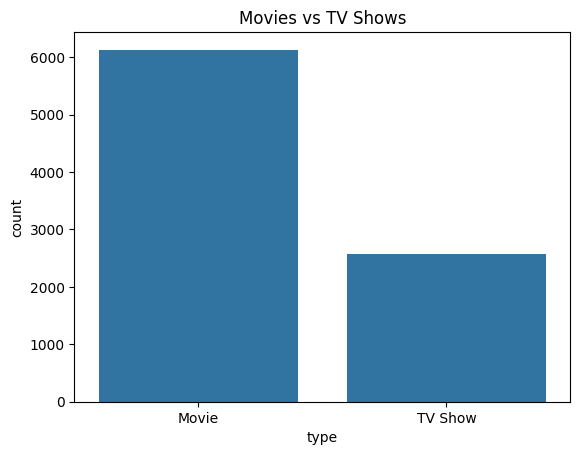

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='type', data=df)
plt.title('Movies vs TV Shows')
plt.show()

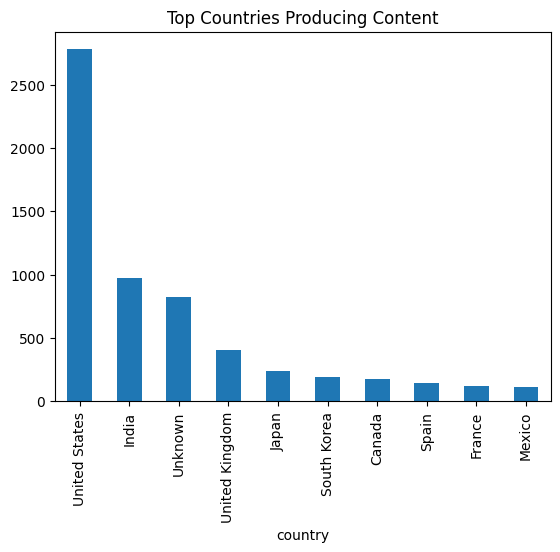

In [12]:
df['country'].value_counts().head(10).plot(kind='bar')
plt.title('Top Countries Producing Content')
plt.show()

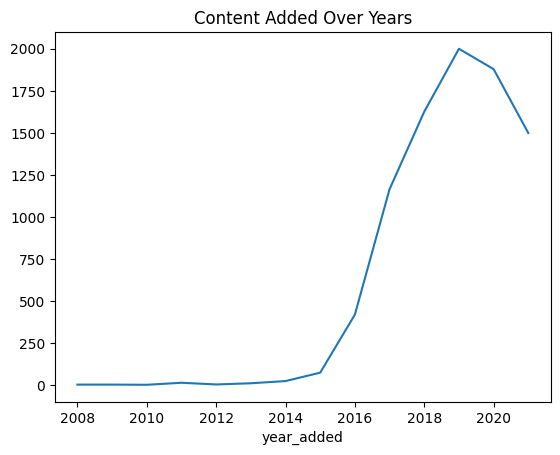

In [13]:
df['year_added'].value_counts().sort_index().plot()
plt.title('Content Added Over Years')
plt.show()

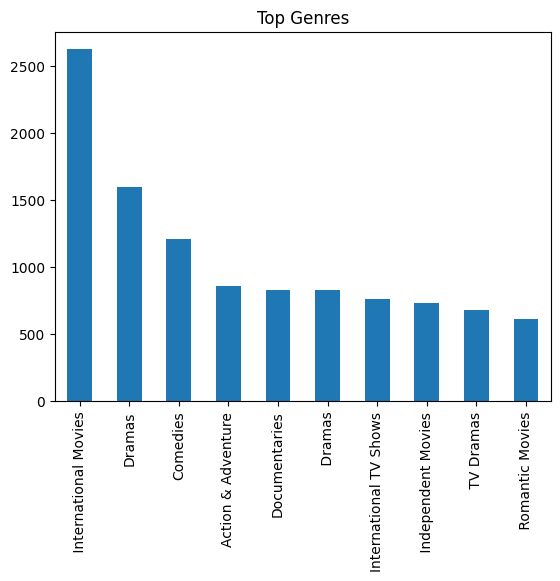

In [14]:
df['listed_in'].str.split(',', expand=True).stack().value_counts().head(10).plot(kind='bar')
plt.title('Top Genres')
plt.show()

In [15]:
import pandas as pd

# Netflix dataset
netflix = pd.read_csv('../data/netflix_titles.csv')

# Bollywood dataset (CSV)
bollywood = pd.read_csv('../data/bollywood_movies.csv')

# Check both
netflix.head()
bollywood.head()

,movie_name,release_year,genre,lead_actor,director,budget_in_crores,box_office_in_crores,imdb_rating,verdict
0,Gully Boy,2019,Drama,Ranveer Singh,Zoya Akhtar,40,238.0,8.0,Hit
1,Pathaan,2023,Action,Shah Rukh Khan,Siddharth Anand,250,1050.0,7.0,Blockbuster
2,Article 370,2024,Thriller,Yami Gautam,Aditya Suhas Jambhale,20,120.0,8.2,Hit
3,Laal Singh Chaddha,2022,Drama,Aamir Khan,Advait Chandan,180,126.0,5.5,Flop
4,War,2019,Action,Hrithik Roshan,Siddharth Anand,150,475.0,6.8,Hit


In [16]:
netflix_india = netflix[netflix['country'].str.contains('India', na=False)]

In [17]:
netflix_recent = netflix_india[netflix_india['release_year'] >= 2018]

In [18]:
netflix_recent = netflix_recent[['title', 'type', 'release_year', 'rating', 'listed_in']]

In [19]:
# Filter recent Bollywood movies
bollywood_recent = bollywood[bollywood['release_year'] >= 2011]

# Rename columns to match Netflix
bollywood_recent = bollywood_recent.rename(columns={
    'movie_name': 'title',
    'genre': 'listed_in',
    'imdb_rating': 'rating'
})

# Add type column
bollywood_recent['type'] = 'Movie'

# Select only needed columns
bollywood_recent = bollywood_recent[['title', 'type', 'release_year', 'rating', 'listed_in']]

bollywood_recent.head()

,title,type,release_year,rating,listed_in
0,Gully Boy,Movie,2019,8.0,Drama
1,Pathaan,Movie,2023,7.0,Action
2,Article 370,Movie,2024,8.2,Thriller
3,Laal Singh Chaddha,Movie,2022,5.5,Drama
4,War,Movie,2019,6.8,Action


In [20]:
netflix_recent.head(20)     # first 20 rows

,title,type,release_year,rating,listed_in
4,Kota Factory,TV Show,2021,TV-MA,"International TV Shows, Romantic TV Shows, TV ..."
39,Chhota Bheem,TV Show,2021,TV-Y7,Kids' TV
126,Shikara,Movie,2020,TV-14,"Dramas, International Movies, Romantic Movies"
190,Thimmarusu,Movie,2021,TV-14,"Dramas, International Movies"
259,Pahuna,Movie,2018,TV-PG,"Comedies, Dramas, International Movies"
266,The Creative Indians,TV Show,2020,TV-MA,"Docuseries, International TV Shows"
297,Navarasa,TV Show,2021,TV-MA,TV Shows
518,Har Kisse Ke Hisse: Kaamyaab,Movie,2020,TV-14,"Dramas, International Movies"
541,Truckbhar Swapna,Movie,2018,TV-14,"Comedies, Dramas, International Movies"
551,Haseen Dillruba,Movie,2021,TV-MA,"International Movies, Romantic Movies, Thrillers"


In [21]:
netflix_recent.tail(20)     # last 20 rows

,title,type,release_year,rating,listed_in
6707,Ethirmarai,Movie,2018,TV-14,"International Movies, Music & Musicals, Thrillers"
6820,Gabru: Hip Hop Revolution,TV Show,2018,TV-14,"International TV Shows, TV Dramas"
6832,Gemini,Movie,2018,TV-PG,Dramas
6993,Hope Aur Hum,Movie,2018,TV-14,"Children & Family Movies, Comedies, Dramas"
7184,Khan: No. 1 Crime Hunter,TV Show,2018,TV-14,"Crime TV Shows, International TV Shows, TV Com..."
7190,Kia and Cosmos,Movie,2018,TV-14,"Dramas, Independent Movies, International Movies"
7361,Lupt,Movie,2018,TV-14,"Horror Movies, International Movies, Thrillers"
7453,Midnight Misadventures With Mallika Dua,TV Show,2018,TV-14,"International TV Shows, Stand-Up Comedy & Talk..."
7595,Norm of the North: Keys to the Kingdom,Movie,2019,TV-PG,Children & Family Movies
7596,Norm of the North: King Sized Adventure,Movie,2019,TV-PG,"Children & Family Movies, Comedies"


In [22]:
custom_data = pd.DataFrame({
    'title': [
        '3 Idiots', 'Dangal', 'Bahubali', 'RRR', 'Sacred Games',
        'Mirzapur', 'The Family Man', 'KGF', 'Drishyam', 'Shershaah'
    ],
    'type': [
        'Movie','Movie','Movie','Movie','TV Show',
        'TV Show','TV Show','Movie','Movie','Movie'
    ],
    'release_year': [
        2009, 2016, 2015, 2022, 2018,
        2018, 2019, 2018, 2015, 2021
    ],
    'rating': [
        '8.4','8.3','8.0','8.2','8.5',
        '8.4','8.7','8.2','8.1','8.4'
    ],
    'listed_in': [
        'Drama','Sports','Action','Action','Crime',
        'Crime','Thriller','Action','Thriller','War'
    ]
})

custom_data

,title,type,release_year,rating,listed_in
0,3 Idiots,Movie,2009,8.4,Drama
1,Dangal,Movie,2016,8.3,Sports
2,Bahubali,Movie,2015,8.0,Action
3,RRR,Movie,2022,8.2,Action
4,Sacred Games,TV Show,2018,8.5,Crime
5,Mirzapur,TV Show,2018,8.4,Crime
6,The Family Man,TV Show,2019,8.7,Thriller
7,KGF,Movie,2018,8.2,Action
8,Drishyam,Movie,2015,8.1,Thriller
9,Shershaah,Movie,2021,8.4,War


In [23]:
combined = pd.concat([netflix_recent, custom_data], ignore_index=True)

In [24]:
combined.tail(15)
combined.shape

(316, 5)

In [25]:
# Convert Bollywood columns to match
bollywood_recent = bollywood[['movie_name','release_year','genre','imdb_rating']]

bollywood_recent.rename(columns={
    'movie_name':'title',
    'genre':'listed_in',
    'imdb_rating':'rating'
}, inplace=True)

bollywood_recent['type'] = 'Movie'

# Combine all
combined = pd.concat([netflix_recent, bollywood_recent, custom_data], ignore_index=True)

In [26]:
combined['favorite'] = combined['title'].isin([
    '3 Idiots','Dangal','Sacred Games','Mirzapur','The Family Man'
])

In [27]:
combined[combined['favorite'] == True]

,title,type,release_year,rating,listed_in,favorite
190,Sacred Games,TV Show,2019,TV-MA,"Crime TV Shows, International TV Shows, TV Dramas",True
315,3 Idiots,Movie,2009,8.4,Comedy,True
556,3 Idiots,Movie,2009,8.4,Drama,True
557,Dangal,Movie,2016,8.3,Sports,True
560,Sacred Games,TV Show,2018,8.5,Crime,True
561,Mirzapur,TV Show,2018,8.4,Crime,True
562,The Family Man,TV Show,2019,8.7,Thriller,True


In [28]:
combined.groupby('favorite')['rating'].count()

favorite
False    559
True       7
Name: rating, dtype: int64

In [29]:
# convert rating to numeric (important for analysis)
combined['rating'] = pd.to_numeric(combined['rating'], errors='coerce')

# ensure favorite column exists
combined['favorite'] = combined['title'].isin([
    '3 Idiots','Dangal','Sacred Games','Mirzapur','The Family Man'
])

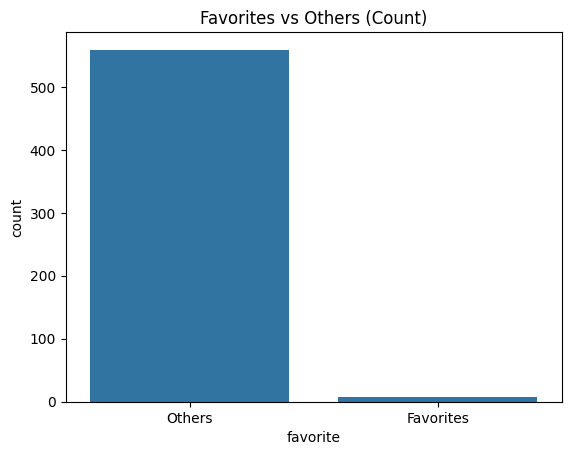

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='favorite', data=combined)
plt.title('Favorites vs Others (Count)')
plt.xticks([0,1], ['Others','Favorites'])
plt.show()

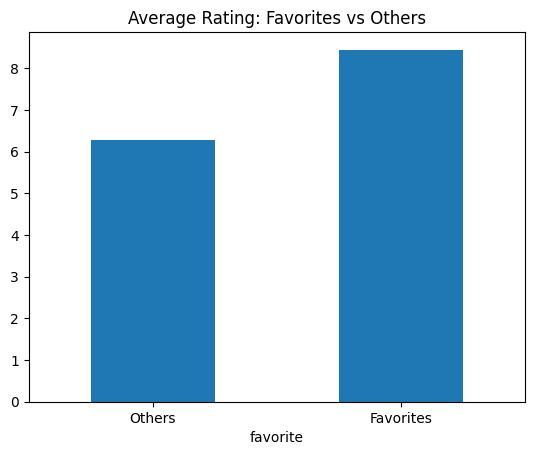

In [31]:
combined.groupby('favorite')['rating'].mean().plot(kind='bar')
plt.title('Average Rating: Favorites vs Others')
plt.xticks([0,1], ['Others','Favorites'], rotation=0)
plt.show()

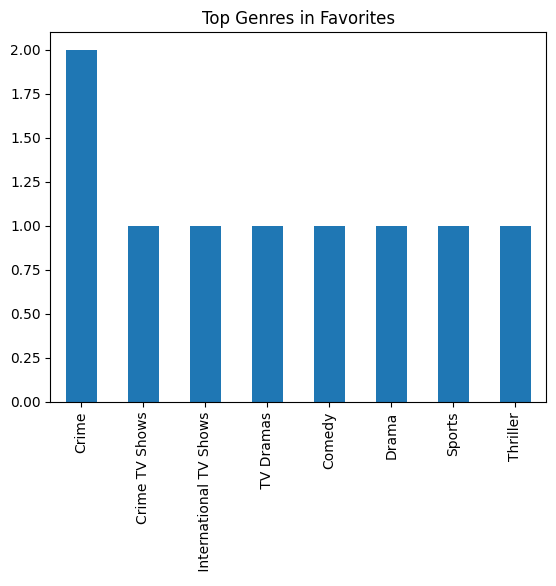

In [32]:
fav_genres = combined[combined['favorite'] == True]['listed_in'] \
    .str.split(',', expand=True).stack().value_counts()

fav_genres.plot(kind='bar')
plt.title('Top Genres in Favorites')
plt.show()

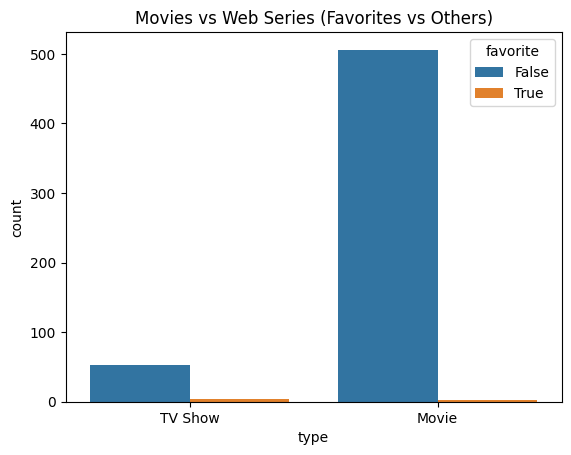

In [33]:
sns.countplot(x='type', hue='favorite', data=combined)
plt.title('Movies vs Web Series (Favorites vs Others)')
plt.show()

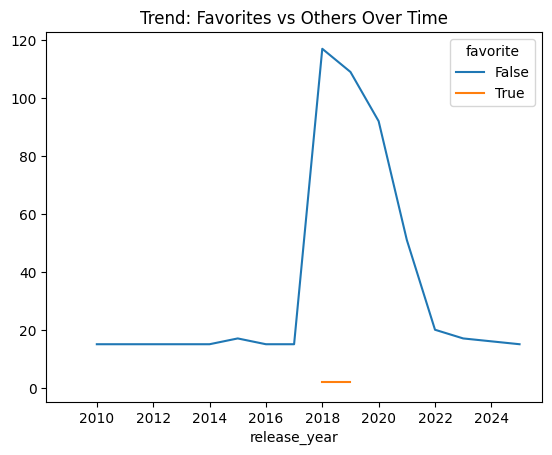

In [34]:
combined.groupby(['release_year','favorite']).size().unstack().plot()
plt.title('Trend: Favorites vs Others Over Time')
plt.show()

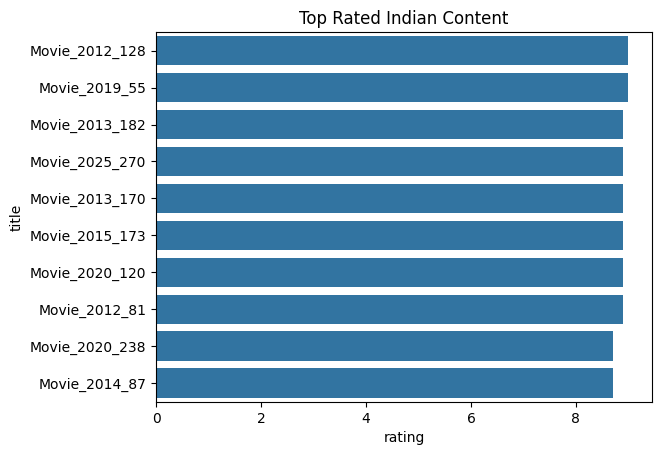

In [35]:
top = combined.sort_values(by='rating', ascending=False).head(10)

sns.barplot(x='rating', y='title', data=top)
plt.title('Top Rated Indian Content')
plt.show()

In [36]:
combined.to_csv('../data/indian_content_analysis.csv', index=False)

In [37]:
# Clean column names (important)
bollywood.columns = bollywood.columns.str.lower().str.strip()

# Convert numeric columns
bollywood['imdb_rating'] = pd.to_numeric(bollywood['imdb_rating'], errors='coerce')
bollywood['box_office_in_crores'] = pd.to_numeric(bollywood['box_office_in_crores'], errors='coerce')
bollywood['budget_in_crores'] = pd.to_numeric(bollywood['budget_in_crores'], errors='coerce')

bollywood.head()

,movie_name,release_year,genre,lead_actor,director,budget_in_crores,box_office_in_crores,imdb_rating,verdict
0,Gully Boy,2019,Drama,Ranveer Singh,Zoya Akhtar,40,238.0,8.0,Hit
1,Pathaan,2023,Action,Shah Rukh Khan,Siddharth Anand,250,1050.0,7.0,Blockbuster
2,Article 370,2024,Thriller,Yami Gautam,Aditya Suhas Jambhale,20,120.0,8.2,Hit
3,Laal Singh Chaddha,2022,Drama,Aamir Khan,Advait Chandan,180,126.0,5.5,Flop
4,War,2019,Action,Hrithik Roshan,Siddharth Anand,150,475.0,6.8,Hit


In [38]:
!pip install plotly ipywidgets


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [39]:
import plotly.express as px
import ipywidgets as widgets
from IPython.display import display

In [40]:
combined.head()

,title,type,release_year,rating,listed_in,favorite
0,Kota Factory,TV Show,2021,NaN,"International TV Shows, Romantic TV Shows, TV ...",False
1,Chhota Bheem,TV Show,2021,NaN,Kids' TV,False
2,Shikara,Movie,2020,NaN,"Dramas, International Movies, Romantic Movies",False
3,Thimmarusu,Movie,2021,NaN,"Dramas, International Movies",False
4,Pahuna,Movie,2018,NaN,"Comedies, Dramas, International Movies",False


In [41]:
type_filter = widgets.Dropdown(
    options=['All'] + list(combined['type'].unique()),
    description='Type:'
)

In [42]:
# Dropdown for type
type_filter = widgets.Dropdown(
    options=['All'] + list(combined['type'].unique()),
    description='Type:'
)

# Slider for year
year_slider = widgets.IntRangeSlider(
    value=[2015, 2025],
    min=int(combined['release_year'].min()),
    max=int(combined['release_year'].max()),
    step=1,
    description='Year Range:'
)

In [43]:
def update_dashboard(type_value, year_range):
    
    df = combined.copy()
    
    # Filter by type
    if type_value != 'All':
        df = df[df['type'] == type_value]
    
    # Filter by year
    df = df[(df['release_year'] >= year_range[0]) & 
            (df['release_year'] <= year_range[1])]
    
    # Plot
    fig = px.histogram(df, x='type', color='favorite',
                       title='Interactive: Movies vs Web Series')
    fig.show()
    
    fig2 = px.line(df.groupby('release_year').size().reset_index(name='count'),
                   x='release_year', y='count',
                   title='Interactive: Content Growth')
    fig2.show()

In [44]:
widgets.interactive(update_dashboard,
                    type_value=type_filter,
                    year_range=year_slider)

interactive(children=(Dropdown(description='Type:', options=('All', 'TV Show', 'Movie'), value='All'), IntRang…

In [45]:
import plotly.express as px
from IPython.display import clear_output

In [46]:
def update_dashboard(type_value, year_range):
    clear_output(wait=True)  # clears old charts → dashboard feel
    
    display(type_filter, year_slider)  # keep controls visible
    
    df = combined.copy()
    
    # Filters
    if type_value != 'All':
        df = df[df['type'] == type_value]
        
    df = df[(df['release_year'] >= year_range[0]) &
            (df['release_year'] <= year_range[1])]
    
    # Chart 1: Type distribution
    fig1 = px.histogram(df, x='type', color='favorite',
                        title='Movies vs Web Series',
                        barmode='group')
    fig1.show()
    
    # Chart 2: Growth trend
    trend = df.groupby('release_year').size().reset_index(name='count')
    fig2 = px.line(trend, x='release_year', y='count',
                   title='Content Growth Over Time')
    fig2.show()
    
    # Chart 3: Top Genres
    genres = df['listed_in'].str.split(',', expand=True).stack().value_counts().head(10)
    fig3 = px.bar(x=genres.index, y=genres.values,
                  title='Top Genres')
    fig3.show()
    
    # Chart 4: Ratings comparison
    fig4 = px.box(df, x='favorite', y='rating',
                  title='Ratings: Favorites vs Others')
    fig4.show()

In [47]:
widgets.interactive(update_dashboard,
                    type_value=type_filter,
                    year_range=year_slider)

interactive(children=(Dropdown(description='Type:', options=('All', 'TV Show', 'Movie'), value='All'), IntRang…

In [48]:
fav_filter = widgets.Dropdown(
    options=['All', True, False],
    description='Favorite:'
)

In [49]:
fav_filter = widgets.Dropdown(
    options=['All', True, False],
    description='Favorite:'
)

In [50]:
def update_dashboard(type_value, year_range, fav_filter_value):
    
    from IPython.display import clear_output
    clear_output(wait=True)
    
    display(type_filter, year_slider, fav_filter)
    
    df = combined.copy()
    
    # Type filter
    if type_value != 'All':
        df = df[df['type'] == type_value]
    
    # Year filter
    df = df[(df['release_year'] >= year_range[0]) &
            (df['release_year'] <= year_range[1])]
    
    # ✅ FIXED favorite filter
    if fav_filter_value != 'All':
        df = df[df['favorite'] == fav_filter_value]
    
    # Plot
    import plotly.express as px
    
    fig = px.histogram(df, x='type', color='favorite',
                       title='Movies vs Web Series')
    fig.show()

In [51]:
search_box = widgets.Text(
    value='',
    placeholder='Search movie or series...',
    description='Search:'
)

In [52]:
def update_dashboard(type_value, year_range, fav_filter_value, search_value):
    
    from IPython.display import clear_output, display
    clear_output(wait=True)
    
    # Show all controls
    display(type_filter, year_slider, fav_filter, search_box)
    
    df = combined.copy()
    
    # Type filter
    if type_value != 'All':
        df = df[df['type'] == type_value]
    
    # Year filter
    df = df[(df['release_year'] >= year_range[0]) &
            (df['release_year'] <= year_range[1])]
    
    # Favorite filter
    if fav_filter_value != 'All':
        df = df[df['favorite'] == fav_filter_value]
    
    # 🔍 Search filter
    if search_value:
        df = df[df['title'].str.contains(search_value, case=False, na=False)]
    
    import plotly.express as px
    
    # 🎯 Chart 1: Type distribution
    fig1 = px.histogram(df, x='type', color='favorite',
                        title='Movies vs Web Series',
                        barmode='group')
    fig1.show()
    
    # 📈 Chart 2: Growth trend
    trend = df.groupby('release_year').size().reset_index(name='count')
    fig2 = px.line(trend, x='release_year', y='count',
                   title='Content Growth Over Time')
    fig2.show()
    
    # 🎭 Chart 3: Top Genres
    genres = df['listed_in'].str.split(',', expand=True).stack().value_counts().head(10)
    fig3 = px.bar(x=genres.index, y=genres.values,
                  title='Top Genres')
    fig3.show()
    
    # ⭐ Chart 4: Rating comparison
    fig4 = px.box(df, x='favorite', y='rating',
                  title='Ratings: Favorites vs Others')
    fig4.show()
    
    # 🏆 TOP 10 LIST (NEW 🔥)
    top10 = df.sort_values(by='rating', ascending=False).head(10)
    
    print("\n🏆 Top 10 Content (Based on Rating):\n")
    display(top10[['title','type','release_year','rating','favorite']])

In [53]:
widgets.interactive(update_dashboard,
                    type_value=type_filter,
                    year_range=year_slider,
                    fav_filter_value=fav_filter,
                    search_value=search_box)

interactive(children=(Dropdown(description='Type:', options=('All', 'TV Show', 'Movie'), value='All'), IntRang…

In [54]:
combined['listed_in'] = combined['listed_in'].fillna('')
combined['rating'] = pd.to_numeric(combined['rating'], errors='coerce')

In [55]:
def recommend_movies(movie_name):
    
    # Find selected movie
    movie = combined[combined['title'].str.contains(movie_name, case=False, na=False)]
    
    if movie.empty:
        print("❌ Movie not found")
        return
    
    # Get genre of selected movie
    genre = movie.iloc[0]['listed_in']
    
    # Filter similar genre
    similar = combined[combined['listed_in'].str.contains(genre.split(',')[0], na=False)]
    
    # Remove same movie
    similar = similar[similar['title'] != movie.iloc[0]['title']]
    
    # Sort by rating
    similar = similar.sort_values(by='rating', ascending=False)
    
    # Top 10 recommendations
    print(f"\n🎬 Recommendations for: {movie.iloc[0]['title']}\n")
    display(similar[['title','type','release_year','rating','favorite']].head(10))

In [56]:
recommend_movies('3 Idiots')


🎬 Recommendations for: 3 Idiots



,title,type,release_year,rating,favorite
335,Movie_2011_102,Movie,2011,8.6,False
539,Movie_2024_242,Movie,2024,8.5,False
338,Movie_2011_36,Movie,2011,8.3,False
514,Movie_2023_39,Movie,2023,7.7,False
417,Movie_2016_8,Movie,2016,7.3,False
530,Movie_2024_93,Movie,2024,7.2,False
525,Movie_2023_201,Movie,2023,7.0,False
401,Movie_2015_59,Movie,2015,6.7,False
334,Movie_2011_135,Movie,2011,6.3,False
432,Movie_2017_143,Movie,2017,6.1,False


In [57]:
recommend_movies('Mirzapur')
recommend_movies('Dangal')


🎬 Recommendations for: Mirzapur



,title,type,release_year,rating,favorite
560,Sacred Games,TV Show,2018,8.5,True
117,Hasmukh,TV Show,2020,NaN,False
127,She,TV Show,2020,NaN,False
150,Jamtara - Sabka Number Ayega,TV Show,2020,NaN,False
190,Sacred Games,TV Show,2019,NaN,True
226,Delhi Crime,TV Show,2019,NaN,False
290,Khan: No. 1 Crime Hunter,TV Show,2018,NaN,False



🎬 Recommendations for: Dangal



,title,type,release_year,rating,favorite
58,Torbaaz,Movie,2020,NaN,False
141,Jada,Movie,2019,NaN,False
260,Soorma,Movie,2018,NaN,False
261,Khido Khundi,Movie,2018,NaN,False
274,Ladies First,Movie,2018,NaN,False


In [58]:
rec_input = widgets.Text(
    value='',
    placeholder='Enter movie name...',
    description='Recommend:'
)

In [59]:
button = widgets.Button(description="Get Recommendations")

def on_button_click(b):
    recommend_movies(rec_input.value)

button.on_click(on_button_click)

display(rec_input, button)

Text(value='', description='Recommend:', placeholder='Enter movie name...')

Button(description='Get Recommendations', style=ButtonStyle())